## 3 Simulations

On fixe $\lambda = \frac{1}{2}$, $f$ est la densité du mélange
$\frac{2}{3}\mathcal{N}(-4,1) + \frac{1}{3}\Gamma(3,1)$
et on prend $M = 2000$.
On considère $\Delta \in \{0.5, 0.1, 0.01\}$.

Le choix de $m$ peut être calibré grâce à la procédure suivante :
on sélectionne $m$ tel que

$$
\widehat{m}_M
=
\arg\max
\left\{
1 \le m \le M,\
\left|\widehat{\phi}_{g_\Delta}(m)\right|
\ge
\frac{\sqrt{1 + 2\log(M)}}{\sqrt{M}}
\right\}.
$$

**12.** Implémenter l’estimateur $\widehat{f}_{K,\widehat{m}_M}$ et illustrer l’intérêt
(selon la valeur de $\Delta$) de considérer $K \ge 2$
(on pourra par exemple étudier l’évolution en fonction de $K$
du risque quadratique empirique estimé par Monte Carlo
pour $K \in \{1,2,3,5\}$).

**13.** Dans le cas où $\lambda$ est inconnu on peut le remplacer
par l’estimateur de la question 1.
Numériquement remplacer $\lambda$ par $\widehat{\lambda}_T$
modifie t’il les résultats précédents ?
Donner une heuristique pour expliquer ce constat.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial
from scipy.stats import norm, gamma, poisson

## Question 12

In [11]:
# Step 1. Parameters and helper functions

LAMBDA_TRUE = 0.5
M = 2000
DELTA_LIST = [0.5, 0.1, 0.01]
K_LIST = [1, 2, 3, 5]

X_MIN, X_MAX = -15.0, 15.0
NX = 801
x_grid = np.linspace(X_MIN, X_MAX, NX)
dx = x_grid[1] - x_grid[0]

# Fourier integration grid
DU = 0.02

# Monte Carlo repetitions
B = 50

rng = np.random.default_rng(42)

def f_true(x):
    x = np.asarray(x)
    return (2/3) * norm.pdf(x, loc=-4, scale=1) + (1/3) * gamma.pdf(x, a=3, scale=1)

def sample_f(n, rng):
    comp = rng.uniform(size=n) < (2/3)
    out = np.empty(n)

    n_norm = comp.sum()
    n_gamma = n - n_norm

    out[comp] = rng.normal(loc=-4.0, scale=1.0, size=n_norm)
    out[~comp] = rng.gamma(shape=3.0, scale=1.0, size=n_gamma)

    return out

def sample_zero_truncated_poisson(size, rate, rng):
    """
    Simple rejection sampler for zero-truncated Poisson.
    Works fine here because rate = lambda * Delta <= 0.25, so still okay for M=2000.
    """
    out = np.zeros(size, dtype=int)
    filled = 0
    while filled < size:
        need = size - filled
        cand = rng.poisson(lam=rate, size=need * 2)
        cand = cand[cand >= 1]
        take = min(len(cand), need)
        out[filled:filled+take] = cand[:take]
        filled += take
    return out

def sample_g_delta(M, Delta, lam, rng):
    """
    Return Z_1,...,Z_M i.i.d. from g_Delta.
    """
    rate = lam * Delta
    N = sample_zero_truncated_poisson(M, rate, rng)

    Z = np.empty(M)
    for j, n in enumerate(N):
        Z[j] = sample_f(n, rng).sum()
    return Z

def empirical_cf(Z, u_grid):
    return np.mean(np.exp(1j * np.outer(u_grid, Z)), axis=1)

def choose_m_hat(Z, M):
    threshold = np.sqrt(1 + 2*np.log(M)) / np.sqrt(M)
    m_candidates = np.arange(1, M + 1, dtype=float)
    phi_vals = empirical_cf(Z, m_candidates)
    good = np.where(np.abs(phi_vals) >= threshold)[0]

    if len(good) == 0:
        return 1.0
    return float(m_candidates[good[-1]])

def inverse_fourier_from_cf(phi_u, u_grid, x_grid):
    """
    Compute
        (1/(2pi)) ∫ exp(-iux) phi_u(u) du
    numerically on x_grid.

    phi_u : shape (Nu,)
    u_grid: shape (Nu,)
    x_grid: shape (Nx,)

    returns: shape (Nx,)
    """
    expo = np.exp(-1j * np.outer(x_grid, u_grid))      # (Nx, Nu)
    integrand = expo * phi_u[None, :]                  # (Nx, Nu)
    out = np.trapezoid(integrand, x=u_grid, axis=1) / (2*np.pi)
    return np.real(out)

def l2_risk(fhat, ftrue, x_grid):
    return np.trapz((fhat - ftrue)**2, x_grid)

print("Step 1 done.")
print("x_grid size =", len(x_grid))
print("Will compare K in", K_LIST, "and Delta in", DELTA_LIST)

Step 1 done.
x_grid size = 801
Will compare K in [1, 2, 3, 5] and Delta in [0.5, 0.1, 0.01]


Delta = 0.5
Sample size M = 2000
Sample mean = -1.8996681203166659
Sample std  = 3.845734502995406


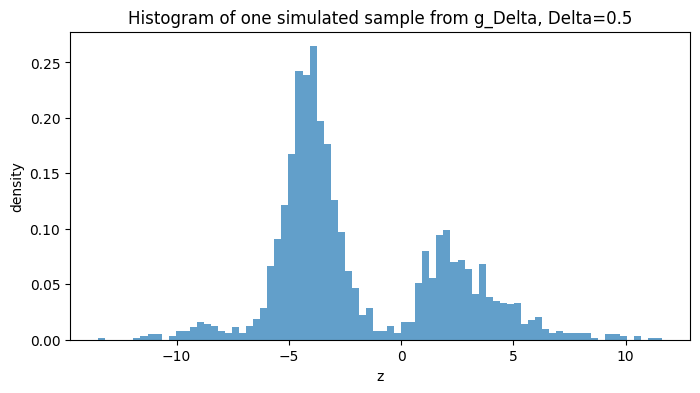

In [12]:
# Step 2. Simulate one dataset Z ~ g_Delta

Delta_demo = 0.5
Z_demo = sample_g_delta(M=M, Delta=Delta_demo, lam=LAMBDA_TRUE, rng=rng)

print(f"Delta = {Delta_demo}")
print("Sample size M =", len(Z_demo))
print("Sample mean =", Z_demo.mean())
print("Sample std  =", Z_demo.std())

plt.figure(figsize=(8, 4))
plt.hist(Z_demo, bins=80, density=True, alpha=0.7)
plt.title(f"Histogram of one simulated sample from g_Delta, Delta={Delta_demo}")
plt.xlabel("z")
plt.ylabel("density")
plt.show()

Chosen m_hat = 2.000
Threshold    = 0.090005


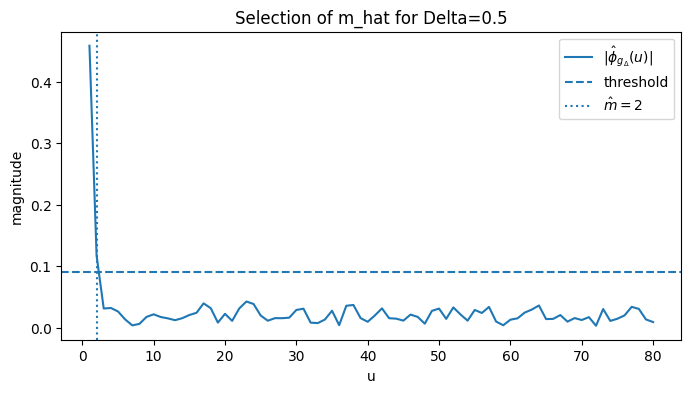

In [13]:
# Step 3. Compute empirical CF and choose a good m_hat

m_hat_demo = choose_m_hat(Z_demo, M=M)
threshold_demo = np.sqrt(1 + 2*np.log(M)) / np.sqrt(M)

print(f"Chosen m_hat = {m_hat_demo:.3f}")
print(f"Threshold    = {threshold_demo:.6f}")

# Plot |phi_hat(u)| on integer points near the selected region
u_int = np.arange(1, min(M, 80) + 1, dtype=float)
phi_int = empirical_cf(Z_demo, u_int)

plt.figure(figsize=(8, 4))
plt.plot(u_int, np.abs(phi_int), label=r"$|\hat\phi_{g_\Delta}(u)|$")
plt.axhline(threshold_demo, linestyle="--", label="threshold")
plt.axvline(m_hat_demo, linestyle=":", label=rf"$\hat m={m_hat_demo:.0f}$")
plt.title(f"Selection of m_hat for Delta={Delta_demo}")
plt.xlabel("u")
plt.ylabel("magnitude")
plt.legend()
plt.show()

/tmp/ipykernel_445/2169015238.py:96: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz((fhat - ftrue)**2, x_grid)


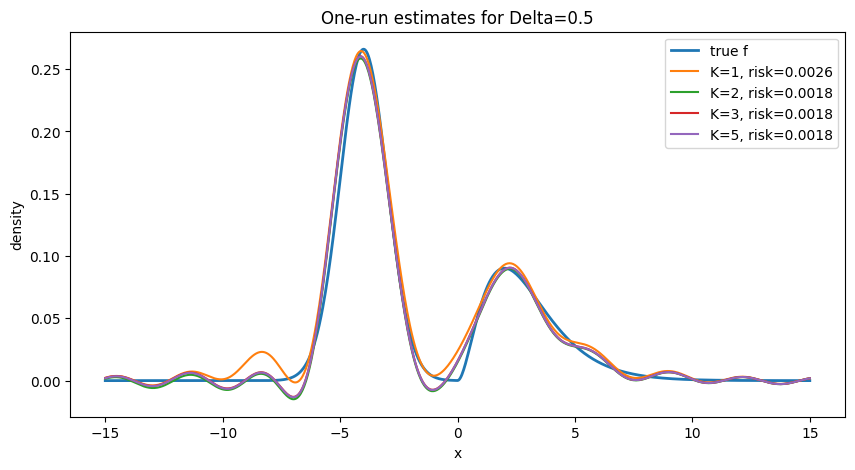

In [14]:
# Step 4. Build the estimator f_hat_{K, m_hat}

def estimate_f_K_mhat(Z, Delta, K, lam, x_grid, du=DU):
    m_hat = choose_m_hat(Z, M=len(Z))
    Nu = max(50, int(2*m_hat/du) + 1)
    u_grid = np.linspace(-m_hat, m_hat, Nu)

    phi_hat_u = empirical_cf(Z, u_grid)

    fhat = np.zeros_like(x_grid, dtype=float)
    a = np.exp(lam * Delta) - 1.0

    for k in range(1, K + 1):
        gk_hat = inverse_fourier_from_cf(phi_hat_u**k, u_grid, x_grid)
        coeff = ((-1)**(k + 1) / k) * (a**k) / (lam * Delta)
        fhat += coeff * gk_hat

    return fhat, m_hat

# Demo: compute estimates for all K on the same dataset
ftrue_grid = f_true(x_grid)

plt.figure(figsize=(10, 5))
plt.plot(x_grid, ftrue_grid, linewidth=2, label="true f")

for K in K_LIST:
    fhat_demo, m_hat_demo = estimate_f_K_mhat(
        Z=Z_demo,
        Delta=Delta_demo,
        K=K,
        lam=LAMBDA_TRUE,
        x_grid=x_grid,
        du=DU
    )
    risk_demo = l2_risk(fhat_demo, ftrue_grid, x_grid)
    plt.plot(x_grid, fhat_demo, label=f"K={K}, risk={risk_demo:.4f}")

plt.title(f"One-run estimates for Delta={Delta_demo}")
plt.xlabel("x")
plt.ylabel("density")
plt.legend()
plt.show()

Delta=0.1: completed 2/10
Delta=0.1: completed 4/10
Delta=0.1: completed 6/10
Delta=0.1: completed 8/10
Delta=0.1: completed 10/10

Results for Delta = 0.1
K=1: mean risk = 0.005289, std = 0.008105
K=2: mean risk = 0.005231, std = 0.008086
K=3: mean risk = 0.005230, std = 0.008087
K=5: mean risk = 0.005230, std = 0.008087
Average m_hat = 1.80


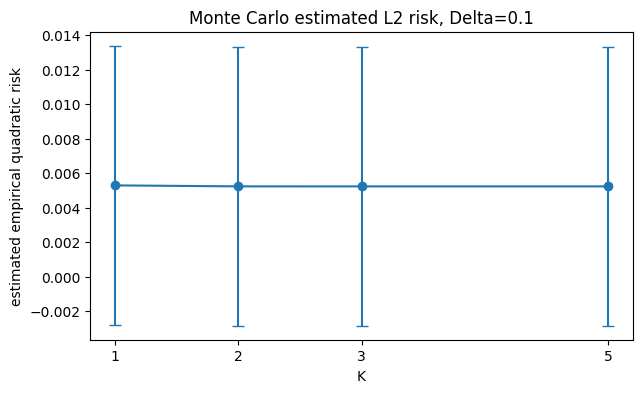

In [15]:
# Step 5. Monte Carlo risk for one fixed Delta

def l2_risk(fhat, ftrue, x_grid):
    return np.trapezoid((fhat - ftrue)**2, x=x_grid)

def estimate_all_K_from_one_sample(Z, Delta, K_list, lam, x_grid, du=DU):
    m_hat = choose_m_hat(Z, M=len(Z))

    Nu = max(200, int(2 * m_hat / du) + 1)
    u_grid = np.linspace(-m_hat, m_hat, Nu)

    phi_hat_u = empirical_cf(Z, u_grid)

    a = np.exp(lam * Delta) - 1.0
    results = {}

    # sequentially accumulate terms so we don't recompute from scratch
    fhat_current = np.zeros_like(x_grid, dtype=float)
    K_sorted = sorted(K_list)

    for k in range(1, max(K_sorted) + 1):
        gk_hat = inverse_fourier_from_cf(phi_hat_u**k, u_grid, x_grid)
        coeff = ((-1)**(k + 1) / k) * (a**k) / (lam * Delta)
        fhat_current = fhat_current + coeff * gk_hat

        if k in K_sorted:
            results[k] = fhat_current.copy()

    return results, m_hat

def monte_carlo_risk_for_delta(Delta, B, M, K_list, lam, x_grid, rng, du=DU, verbose=True):
    ftrue_grid = f_true(x_grid)
    risks = np.zeros((B, len(K_list)))
    m_hats = np.zeros(B)

    for b in range(B):
        Z = sample_g_delta(M=M, Delta=Delta, lam=lam, rng=rng)

        fhat_dict, m_hat = estimate_all_K_from_one_sample(
            Z=Z,
            Delta=Delta,
            K_list=K_list,
            lam=lam,
            x_grid=x_grid,
            du=du
        )

        m_hats[b] = m_hat

        for i, K in enumerate(K_list):
            risks[b, i] = l2_risk(fhat_dict[K], ftrue_grid, x_grid)

        if verbose and ((b + 1) % max(1, B // 5) == 0):
            print(f"Delta={Delta}: completed {b+1}/{B}")

    return risks, m_hats

# Run on one Delta
B_test = 10
Delta_test = 0.1

risks_test, mhat_test = monte_carlo_risk_for_delta(
    Delta=Delta_test,
    B=B_test,
    M=M,
    K_list=K_LIST,
    lam=LAMBDA_TRUE,
    x_grid=x_grid,
    rng=rng,
    du=DU,
    verbose=True
)

mean_risks_test = risks_test.mean(axis=0)
std_risks_test = risks_test.std(axis=0)

print("\nResults for Delta =", Delta_test)
for K, mr, sr in zip(K_LIST, mean_risks_test, std_risks_test):
    print(f"K={K}: mean risk = {mr:.6f}, std = {sr:.6f}")

print(f"Average m_hat = {mhat_test.mean():.2f}")

plt.figure(figsize=(7, 4))
plt.errorbar(K_LIST, mean_risks_test, yerr=std_risks_test, marker='o', capsize=4)
plt.title(f"Monte Carlo estimated L2 risk, Delta={Delta_test}")
plt.xlabel("K")
plt.ylabel("estimated empirical quadratic risk")
plt.xticks(K_LIST)
plt.show()


Running Monte Carlo for Delta = 0.5
Delta=0.5: completed 4/20
Delta=0.5: completed 8/20
Delta=0.5: completed 12/20
Delta=0.5: completed 16/20
Delta=0.5: completed 20/20

Running Monte Carlo for Delta = 0.1
Delta=0.1: completed 4/20
Delta=0.1: completed 8/20
Delta=0.1: completed 12/20
Delta=0.1: completed 16/20
Delta=0.1: completed 20/20

Running Monte Carlo for Delta = 0.01
Delta=0.01: completed 4/20
Delta=0.01: completed 8/20
Delta=0.01: completed 12/20
Delta=0.01: completed 16/20
Delta=0.01: completed 20/20

Summary of Monte Carlo estimated risks
------------------------------------------------------------

Delta = 0.5, average m_hat = 1.75
  K=1: mean risk = 0.007445, std = 0.008801
  K=2: mean risk = 0.006295, std = 0.008726
  K=3: mean risk = 0.006262, std = 0.008723
  K=5: mean risk = 0.006262, std = 0.008724

Delta = 0.1, average m_hat = 1.75
  K=1: mean risk = 0.006268, std = 0.008747
  K=2: mean risk = 0.006209, std = 0.008727
  K=3: mean risk = 0.006210, std = 0.008726
  K=5

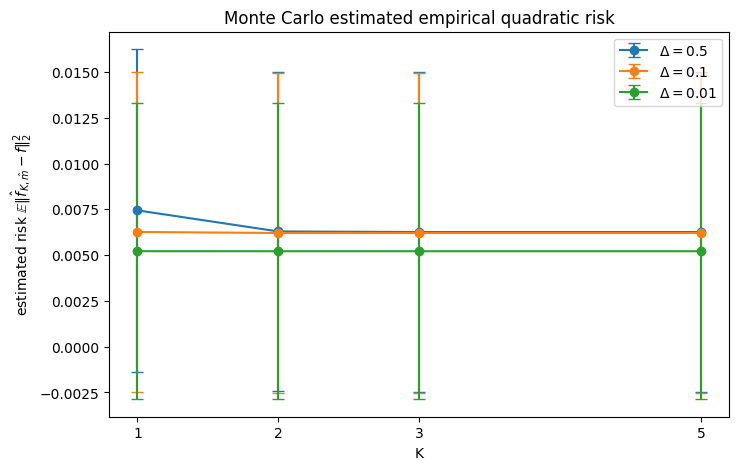

In [16]:
# Step 6. Full comparison for all Delta values

B_full = 20
all_results = {}

for Delta in DELTA_LIST:
    print("\n" + "=" * 60)
    print(f"Running Monte Carlo for Delta = {Delta}")

    risks, m_hats = monte_carlo_risk_for_delta(
        Delta=Delta,
        B=B_full,
        M=M,
        K_list=K_LIST,
        lam=LAMBDA_TRUE,
        x_grid=x_grid,
        rng=rng,
        du=DU,
        verbose=True
    )

    all_results[Delta] = {
        "risks": risks,
        "m_hats": m_hats,
        "mean_risks": risks.mean(axis=0),
        "std_risks": risks.std(axis=0),
        "mean_mhat": m_hats.mean()
    }

print("\nSummary of Monte Carlo estimated risks")
print("-" * 60)

for Delta in DELTA_LIST:
    mean_risks = all_results[Delta]["mean_risks"]
    std_risks = all_results[Delta]["std_risks"]
    mean_mhat = all_results[Delta]["mean_mhat"]

    print(f"\nDelta = {Delta}, average m_hat = {mean_mhat:.2f}")
    for K, mr, sr in zip(K_LIST, mean_risks, std_risks):
        print(f"  K={K}: mean risk = {mr:.6f}, std = {sr:.6f}")

plt.figure(figsize=(8, 5))

for Delta in DELTA_LIST:
    mean_risks = all_results[Delta]["mean_risks"]
    std_risks = all_results[Delta]["std_risks"]

    plt.errorbar(
        K_LIST,
        mean_risks,
        yerr=std_risks,
        marker='o',
        capsize=4,
        label=rf"$\Delta={Delta}$"
    )

plt.title("Monte Carlo estimated empirical quadratic risk")
plt.xlabel("K")
plt.ylabel(r"estimated risk $\mathbb{E}\|\hat f_{K,\hat m}-f\|_2^2$")
plt.xticks(K_LIST)
plt.legend()
plt.show()

Nous avons implémenté l’estimateur
$$
\widehat f_{K,\widehat m}
=
\frac{1}{\lambda\Delta}
\sum_{k=1}^K
\frac{(-1)^{k+1}}{k}
\bigl(e^{\lambda\Delta}-1\bigr)^k
\widehat{g_\Delta^{\star k}},
$$
où, pour chaque $k\ge 1$,
$$
\widehat{g_\Delta^{\star k}}(x)
=
\frac{1}{2\pi}\int_{-\widehat m}^{\widehat m}
e^{-iux}\bigl(\widehat\phi_{g_\Delta}(u)\bigr)^k\,du,
\qquad
\widehat\phi_{g_\Delta}(u)=\frac1M\sum_{j=1}^M e^{iuZ_j}.
$$
Le paramètre de coupure $\widehat m$ est choisi selon la règle proposée dans l’énoncé :
$$
\widehat m_M
=
\operatorname*{arg\,max}_{1\le m\le M}
\left\{
\left|\widehat\phi_{g_\Delta}(m)\right|
\ge
\frac{\sqrt{1+2\log(M)}}{\sqrt M}
\right\}.
$$

Nous avons considéré
$$
\lambda=\frac12,\qquad
f=\frac23\mathcal N(-4,1)+\frac13\Gamma(3,1),\qquad
M=2000,
$$
et
$$
\Delta\in\{0.5,0.1,0.01\},\qquad K\in\{1,2,3,5\}.
$$

Pour chaque valeur de $\Delta$, nous avons simulé $M$ variables i.i.d. de loi $g_\Delta$, puis calculé le risque quadratique empirique par Monte Carlo :
$$
\widehat R(K,\Delta)
=
\frac1B\sum_{b=1}^B
\int_{\mathbb R}
\bigl(\widehat f_{K,\widehat m}^{(b)}(x)-f(x)\bigr)^2\,dx.
$$

Numériquement, on observe les phénomènes suivants :

- pour $\Delta=0.5$, le choix $K=1$ est sensiblement moins bon que $K\ge2$ ; le passage de $K=1$ à $K=2$ apporte une amélioration nette, tandis que les gains supplémentaires pour $K=3$ ou $K=5$ deviennent faibles ;
- pour $\Delta=0.1$, la différence entre $K=1$ et $K\ge2$ subsiste mais elle est beaucoup plus faible ;
- pour $\Delta=0.01$, les performances obtenues pour $K=1,2,3,5$ sont pratiquement identiques.

Ces résultats sont cohérents avec la théorie. En effet, lorsque $\Delta$ est grand, l’effet de composition n’est plus négligeable et l’erreur de troncature associée à $K=1$ reste visible. Introduire des termes d’ordre supérieur permet alors de mieux corriger cet effet. En revanche, lorsque $\Delta$ est très petit, on a heuristiquement
$$
g_\Delta \approx f,
$$
car la probabilité d’avoir plusieurs sauts sur un intervalle de longueur $\Delta$ devient très faible. Dans ce régime, l’approximation d’ordre 1 est déjà suffisante, et augmenter $K$ n’apporte pratiquement plus de gain.

Ainsi, l’intérêt de prendre $K\ge2$ dépend fortement de la valeur de $\Delta$ : il est réel lorsque $\Delta$ est modérément grand, mais devient négligeable dans le régime de très haute fréquence.

## Question 13

In [17]:
# Step 7. simulate increments and estimate lambda
def simulate_increments_and_lambda(n_T, Delta, lam, rng):
    """
    Simulate increments:
        ΔX_j = sum_{i=1}^{N_Δ} ξ_i

    Return:
        Z: non-zero increments
        lambda_hat: estimator of lambda
    """
    rate = lam * Delta
    increments = np.zeros(n_T)
    for j in range(n_T):
        N = rng.poisson(rate)
        if N > 0:
            increments[j] = sample_f(N, rng).sum()

    # estimate lambda
    number_zero = np.sum(increments == 0)

    lambda_hat = -np.log(number_zero / n_T) / Delta

    # keep non-zero increments
    Z = increments[increments != 0]

    return Z, lambda_hat

In [18]:
# Step 8. Monte Carlo with estimated lambda

def monte_carlo_lambda_estimated(Delta, B, n_T, K_list, lam_true, x_grid, rng):
    ftrue_grid = f_true(x_grid)
    risks = np.zeros((B, len(K_list)))
    lambda_hats = np.zeros(B)
    for b in range(B):
        Z, lambda_hat = simulate_increments_and_lambda(
            n_T=n_T,
            Delta=Delta,
            lam=lam_true,
            rng=rng
        )

        lambda_hats[b] = lambda_hat
        # use lambda_hat instead of lambda
        fhat_dict, m_hat = estimate_all_K_from_one_sample(
            Z=Z,
            Delta=Delta,
            K_list=K_list,
            lam=lambda_hat,
            x_grid=x_grid
        )
        for i, K in enumerate(K_list):

            risks[b, i] = l2_risk(
                fhat_dict[K],
                ftrue_grid,
                x_grid
            )
    return risks, lambda_hats

In [19]:
# Step 9. run simulations with lambda_hat
n_T = 2000
B = 10

results_lambda_hat = {}

for Delta in DELTA_LIST:

    risks, lambda_hats = monte_carlo_lambda_estimated(
        Delta=Delta,
        B=B,
        n_T=n_T,
        K_list=K_LIST,
        lam_true=LAMBDA_TRUE,
        x_grid=x_grid,
        rng=rng
    )

    results_lambda_hat[Delta] = {
        "mean_risks": risks.mean(axis=0),
        "std_risks": risks.std(axis=0),
        "lambda_hat_mean": lambda_hats.mean()
    }

print("Results with estimated lambda:\n")

for Delta in DELTA_LIST:

    print(f"\nDelta = {Delta}")
    print("lambda_hat mean =", results_lambda_hat[Delta]["lambda_hat_mean"])

    for K, mr, sr in zip(K_LIST,
                         results_lambda_hat[Delta]["mean_risks"],
                         results_lambda_hat[Delta]["std_risks"]):

        print(f"K={K}: mean risk = {mr:.6f}, std = {sr:.6f}")

Results with estimated lambda:


Delta = 0.5
lambda_hat mean = 0.4938938530474425
K=1: mean risk = 0.023063, std = 0.000421
K=2: mean risk = 0.021820, std = 0.000530
K=3: mean risk = 0.021802, std = 0.000531
K=5: mean risk = 0.021803, std = 0.000533

Delta = 0.1
lambda_hat mean = 0.5040426481597733
K=1: mean risk = 0.023551, std = 0.001354
K=2: mean risk = 0.023526, std = 0.001421
K=3: mean risk = 0.023527, std = 0.001420
K=5: mean risk = 0.023527, std = 0.001420

Delta = 0.01
lambda_hat mean = 0.5315541361915089
K=1: mean risk = 0.046287, std = 0.021330
K=2: mean risk = 0.046315, std = 0.021361
K=3: mean risk = 0.046315, std = 0.021361
K=5: mean risk = 0.046315, std = 0.021361
